In [1]:
from pathlib import Path
from pprint import pprint

import cv2
import numpy as np
from cv2.typing import MatLike

from utils import (
    get_img,
    process_single_img,
    reset_author_dir,
    show_images,
    show_img,
)


In [ ]:
work_dir = Path("./dataset/works")
preprocessing_res_dir = Path("./dataset/preprocessed")

authors = ["kalist", "richard", "zhafif"]

author_map = {
    author: {
        "original": work_dir / author,
        "preprocessed": preprocessing_res_dir / author,
    }
    for author in authors
}


def process_dataset() -> None:
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp"}

    for author, paths in author_map.items():
        work_dir = paths["original"]
        save_dir = paths["preprocessed"]

        reset_author_dir(save_dir)
        if not work_dir.exists():
            print(f"Direktori tidak ditemukan: {work_dir}")
            continue

        print(f"Memproses gambar untuk {author.capitalize()}")
        for file_path in work_dir.iterdir():
            if file_path.suffix.lower() in valid_ext:
                output_path = save_dir / file_path.name
                process_single_img(file_path, output_path)


In [3]:
process_dataset()

Memproses gambar untuk Kalist
Berhasil memproses: healthy.0.jpg -> dataset\preprocessed\kalist\healthy.0.jpg
Berhasil memproses: healthy.1.jpg -> dataset\preprocessed\kalist\healthy.1.jpg
Berhasil memproses: healthy.10.jpg -> dataset\preprocessed\kalist\healthy.10.jpg
Berhasil memproses: healthy.11.jpg -> dataset\preprocessed\kalist\healthy.11.jpg
Berhasil memproses: healthy.12.jpg -> dataset\preprocessed\kalist\healthy.12.jpg
Berhasil memproses: healthy.13.jpg -> dataset\preprocessed\kalist\healthy.13.jpg
Berhasil memproses: healthy.14.jpg -> dataset\preprocessed\kalist\healthy.14.jpg
Berhasil memproses: healthy.15.jpg -> dataset\preprocessed\kalist\healthy.15.jpg
Berhasil memproses: healthy.16.jpg -> dataset\preprocessed\kalist\healthy.16.jpg
Berhasil memproses: healthy.17.jpg -> dataset\preprocessed\kalist\healthy.17.jpg
Berhasil memproses: healthy.18.jpg -> dataset\preprocessed\kalist\healthy.18.jpg
Berhasil memproses: healthy.19.jpg -> dataset\preprocessed\kalist\healthy.19.jpg
Be

{'Coccidiosis (Original)': 'Shape: (224, 224, 3)',
 'Coccidiosis (Preprocessed)': 'Shape: (195, 118, 3)',
 'Healthy (Original)': 'Shape: (224, 224, 3)',
 'Healthy (Preprocessed)': 'Shape: (191, 152, 3)',
 'Newcastle (Original)': 'Shape: (224, 224, 3)',
 'Newcastle (Preprocessed)': 'Shape: (183, 170, 3)',
 'Salmonella (Original)': 'Shape: (224, 224, 3)',
 'Salmonella (Preprocessed)': 'Shape: (224, 224, 3)'}


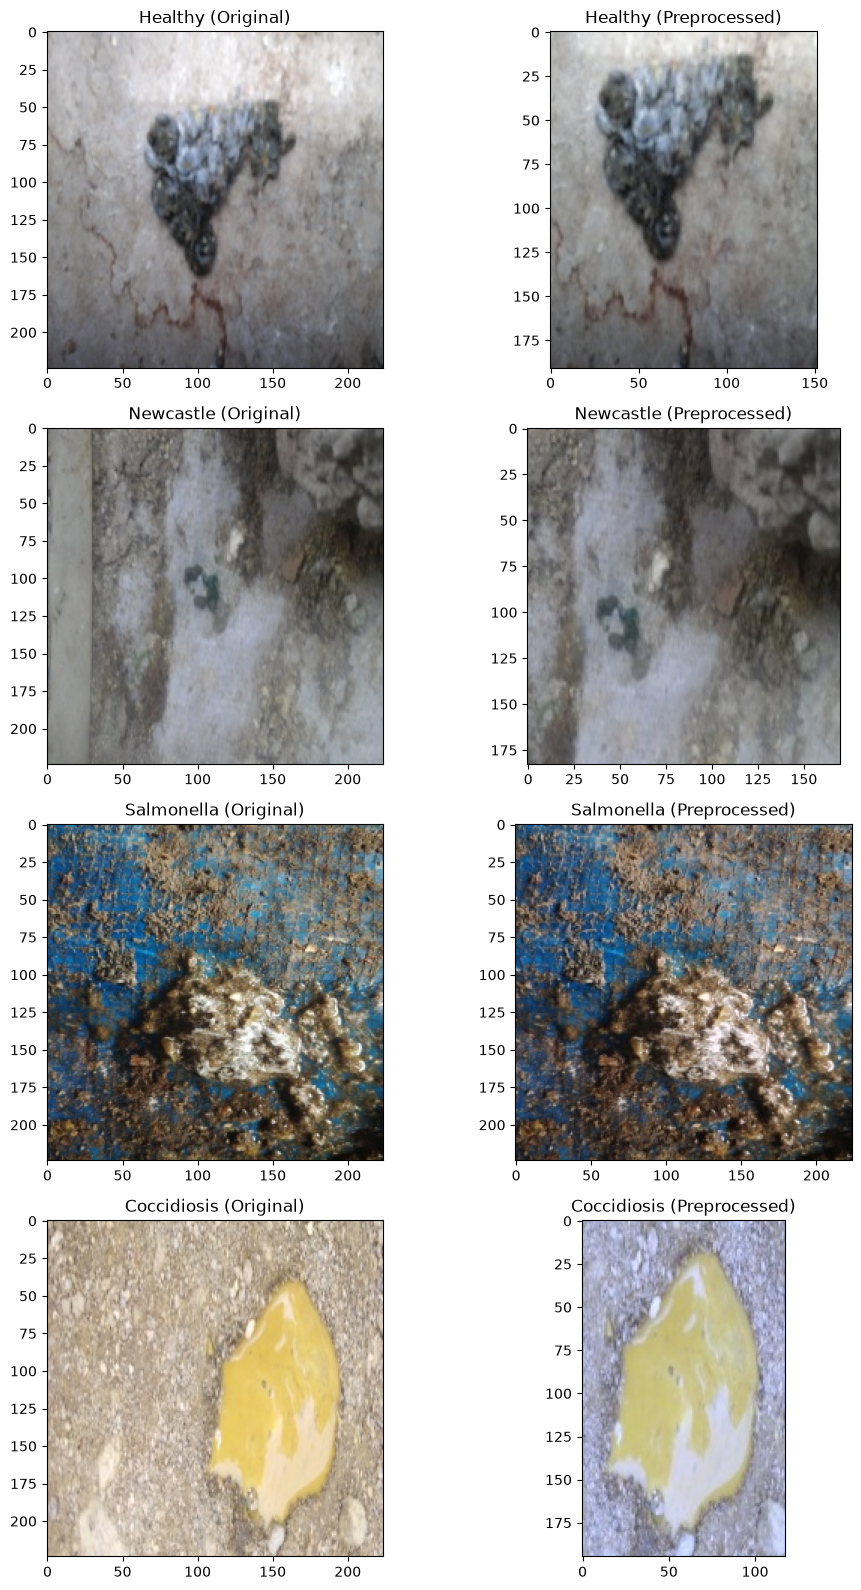

In [7]:
kalist_path = author_map["kalist"]
richard_path = author_map["richard"]
zhafif_path = author_map["zhafif"]

healthy = f"healthy.{np.random.randint(low=0, high=50)}.jpg"
ncd = f"ncd.{np.random.randint(low=50, high=100)}.jpg"
pcrsalmo = f"pcrsalmo.{np.random.randint(low=0, high=50)}.jpg"
cocci = f"cocci.{np.random.randint(low=0, high=50)}.jpg"

healthy_samples = [
    (status.capitalize(), get_img(path / healthy))
    for status, path in kalist_path.items()
]
ncd_samples = [
    (status.capitalize(), get_img(path / ncd)) for status, path in kalist_path.items()
]
salmo_samples = [
    (status.capitalize(), get_img(path / pcrsalmo))
    for status, path in richard_path.items()
]
cocci_samples = [
    (status.capitalize(), get_img(path / cocci)) for status, path in zhafif_path.items()
]

all_pairs = [
    ("Healthy", healthy_samples),
    ("Newcastle", ncd_samples),
    ("Salmonella", salmo_samples),
    ("Coccidiosis", cocci_samples),
]

samples: dict[str, MatLike] = {}

for category, pair_list in all_pairs:
    for status, img in pair_list:
        if img is not None:
            key = f"{category} ({status})"
            samples[key] = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Menampilkan representasi bentuk matriks (shape) agar output pprint ringkas dan mudah dibaca
pprint({key: f"Shape: {img.shape}" for key, img in samples.items()})

show_images(samples, ncols=2, hist_cfg={"show_hist": False})

Berhasil memproses: cocci.37.jpg -> dataset\preprocessed\zhafif\cocci.37.jpg


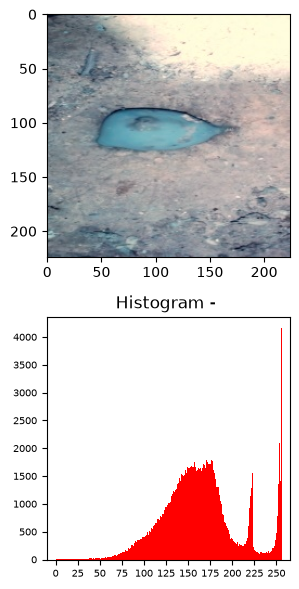

In [2]:
inpath = Path("dataset/works/zhafif/cocci.37.jpg")
outpath = Path("dataset/preprocessed/zhafif/cocci.37.jpg")

result = process_single_img(inpath, outpath, return_result=True)

if result is not None:
    show_img(result, title="")
